To Develop a Machine Learning Classification Model for Predicting Human Hepatic Microsomal Clearance Risk (High vs. Low) as a Pharmacokinetic Determinant of Systemic Drug Exposure (AUC) from Drug Chemical Structure

To Develop a Machine Learning Classification Model for Predicting Human Hepatic Microsomal Clearance Risk (High vs. Low) from Drug Chemical Structure, as a Structural Determinant of Systemic Drug Exposure (AUC)

Object:
To use chemical structure-derived molecular fingerprints and supervised machine learning to predict a drug's likely hepatic clearance category, thereby providing an early, structure-based indicator of expected systemic drug exposure (AUC) before any in vivo pharmacokinetic study is conducted.


This practical uses binary classification, not multi-label.
The two labels are:

0 = Low Clearance (metabolized slowly → expected higher AUC/systemic exposure at a given dose)
1 = High Clearance (metabolized quickly → expected lower AUC/systemic exposure at a given dose)

These came from Block 3, where the continuous log_HLM_CLint value was split at its median (1.205) into these two categories — creating a naturally balanced dataset of roughly 1,544 vs. 1,543 compounds, one label per compound (unlike the ADR practical, where each drug could carry multiple labels simultaneously out of 27 possible categories).

Objectives:

To understand the fundamental pharmacokinetic relationship between clearance, dose, bioavailability, and AUC (AUC = Dose/Clearance for IV; AUC = Dose × F/Clearance for oral administration), and why AUC itself cannot be predicted from chemical structure alone.
To source and validate a real, peer-reviewed, industry-generated dataset (Genentech's public ADME dataset) containing experimentally measured human liver microsomal intrinsic clearance (HLM CLint) values for real drug-like compounds.
To recognize and correctly interpret assay-related data characteristics, such as detection-limit censoring, and to make an informed methodological decision (converting a partly-censored continuous endpoint into a reliable binary classification target) rather than forcing a modeling approach the data cannot properly support.
To convert drug SMILES structures into Morgan fingerprints as machine-learning-ready numerical features.
To train and evaluate a Random Forest classifier that predicts whether a compound is likely to exhibit high or low hepatic clearance, using appropriate classification metrics (ROC-AUC, precision, recall, F1-score, confusion matrix).
To apply the trained model to predict clearance risk for new or untested drug structures, and to correctly interpret what that prediction does and does not imply about a drug's actual systemic exposure (AUC).

Outcome:

After completing this practical, a student will be able to:

Explain the mathematical relationship linking clearance, dose, bioavailability, and AUC, and identify which of these quantities can realistically be predicted from chemical structure alone.
Recognize when a continuous experimental endpoint (such as an enzymatic clearance assay) is affected by assay detection limits, and understand how such censoring can distort naive regression modeling.
Justify, with evidence, the decision to reframe a noisy continuous prediction target as a well-chosen binary classification problem, and compare model performance (R² vs. AUC) to support that decision quantitatively rather than by assumption.
Build a complete structure-to-property classification pipeline: fingerprint generation, train/test splitting, model training, and multi-metric evaluation.
Correctly use a trained clearance-risk model to flag compounds likely to require dose adjustment or reformulation early in a discovery pipeline, while clearly distinguishing this from a direct, literal prediction of a drug's AUC in a real patient.

In [1]:
# Block 1: Load the pharmacokinetic clearance dataset from GitHub
import pandas as pd
import numpy as np

url = "https://github.com/drpharmacy/pharma-ml-projects/raw/refs/heads/main/Excel_Files/pk_clearance_dataset.xlsx"
df = pd.read_excel(url)

print(df.shape)
df.head()

(3087, 2)


,canonical_smiles,log_HLM_CLint
0,CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...,0.675687
1,CCOc1cc2nn(CCC(C)(C)O)cc2cc1NC(=O)c1cccc(C(F)F)n1,0.675687
2,CN(c1ncc(F)cn1)[C@H]1CCCNC1,0.675687
3,CC(C)(Oc1ccc(-c2cnc(N)c(-c3ccc(Cl)cc3)c2)cc1)C...,0.675687
4,CC(C)(O)CCn1cc2cc(NC(=O)c3cccc(C(F)(F)F)n3)c(C...,0.996380


Meaning of Block 1:
Purpose: Load the real, Genentech-published human liver microsomal clearance dataset directly from GitHub, establishing the notebook's starting point.
What data comes IN: Nothing — this is the notebook's starting point.
What happens inside — line by line: url points to pk_clearance_dataset.xlsx in your GitHub Excel_Files/ folder, same raw-link pattern as every earlier notebook. pd.read_excel(url) reads it directly into a DataFrame.
What comes OUT: df — a DataFrame with 3,087 rows and 2 columns (canonical_smiles, log_HLM_CLint), used throughout the rest of the notebook.

count    3087.000000
mean        1.320019
std         0.623952
min         0.675687
25%         0.675687
50%         1.205313
75%         1.803115
max         3.372714
Name: log_HLM_CLint, dtype: float64

Compounds at the exact minimum value: 958 out of 3087 (31.0%)


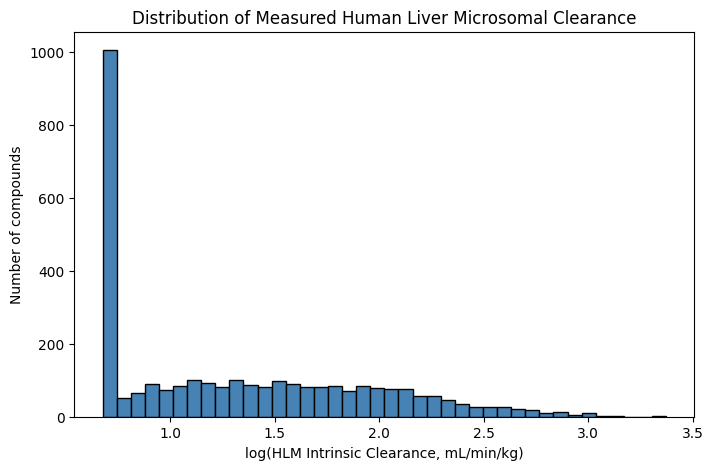

In [2]:
# Block 2: Explore the clearance data and understand its distribution
print(df['log_HLM_CLint'].describe())

at_floor = (df['log_HLM_CLint'] == df['log_HLM_CLint'].min()).sum()
print(f"\nCompounds at the exact minimum value: {at_floor} out of {df.shape[0]} ({at_floor/df.shape[0]*100:.1f}%)")

import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(df['log_HLM_CLint'], bins=40, color='steelblue', edgecolor='black')
plt.xlabel("log(HLM Intrinsic Clearance, mL/min/kg)")
plt.ylabel("Number of compounds")
plt.title("Distribution of Measured Human Liver Microsomal Clearance")
plt.show()

Meaning of Block 2:
Purpose: Understand the shape of the real measured clearance data before deciding how to model it — this exploration is what led to the classification framing used in the rest of the notebook.
What data comes IN: df from Block 1.
What happens inside — line by line: .describe() summarizes the spread of clearance values (min 0.68, max 3.37, on the log scale). The at_floor calculation counts how many compounds share the exact minimum value — this returns 958 compounds (31%), which is a strong signal of assay censoring: liver microsomal clearance assays have a practical lower detection limit, so any compound metabolized too slowly to measure precisely gets recorded at that same floor value rather than its true (even lower) rate. This isn't a data error — it's a real, common characteristic of this kind of experimental assay. The histogram visualizes this directly: expect a large spike at the leftmost bar (the floored compounds) rather than a smooth bell curve.
What comes OUT: Nothing new is created — this exploration is what motivates Block 3's decision to convert the noisy, partially-censored continuous value into a more reliable binary classification target.

In [3]:
# Block 3: Convert the continuous clearance value into a binary "high vs low clearance" target
median_clearance = df['log_HLM_CLint'].median()
df['high_clearance'] = (df['log_HLM_CLint'] > median_clearance).astype(int)

print(f"Median split point: {median_clearance:.3f}")
print(df['high_clearance'].value_counts())
print("\n1 = High clearance (metabolized quickly -> expect LOWER AUC for a given dose)")
print("0 = Low clearance (metabolized slowly -> expect HIGHER AUC for a given dose)")

Median split point: 1.205
high_clearance
0    1544
1    1543
Name: count, dtype: int64

1 = High clearance (metabolized quickly -> expect LOWER AUC for a given dose)
0 = Low clearance (metabolized slowly -> expect HIGHER AUC for a given dose)


Meaning of Block 3:
Purpose: Reframe the modeling target from an exact, partly-censored numeric value into a clean binary question a model can answer reliably: is this compound likely to have high or low clearance?
What data comes IN: df['log_HLM_CLint'] from Block 1.
What happens inside — line by line: median_clearance finds the exact midpoint of all 3,087 measured values. high_clearance labels every compound above that midpoint as 1 (high clearance) and everything at or below it as 0 (low clearance) — a median split naturally produces a near-perfectly balanced dataset (confirmed by the printed counts), avoiding the class-imbalance problems seen in earlier notebooks. This directly ties back to the AUC relationship explained earlier: since AUC = Dose / Clearance, a compound predicted as high clearance is expected to produce lower drug exposure (AUC) at a given dose, and vice versa for low clearance — this is the real pharmacokinetic reasoning connecting this practical back to its stated goal.
What comes OUT: df['high_clearance'] — a new binary column (0/1), which becomes the prediction target y in the next block.

In [4]:
# Block 4: Convert drug structures into Morgan fingerprint features
!pip install rdkit -q

from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator, DataStructs

fp_generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

def get_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = fp_generator.GetFingerprint(mol)
    arr = np.zeros((1024,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

X = np.array([get_fingerprint(s) for s in df['canonical_smiles']])
y = df['high_clearance'].values

print("X shape:", X.shape)
print("y shape:", y.shape)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 37.5 MB/s eta 0:00:00
X shape: (3087, 1024)
y shape: (3087,)


Meaning of Block 4:
Purpose: Convert every compound's chemical structure into the fixed-length numeric input the model will actually learn from.
What data comes IN: df['canonical_smiles'] from Block 1; df['high_clearance'] from Block 3.
What happens inside — line by line: Same 1024-bit Morgan (ECFP4) fingerprinting approach used throughout this series — RDKit is installed fresh since every new Colab session starts with a clean environment. get_fingerprint() converts one SMILES string into a 1024-length binary array encoding its substructures.
What comes OUT: X — shape (3087, 1024), one fingerprint per compound; y — shape (3087,), the binary high/low clearance label, both feeding into Block 5.

In [5]:
# Block 5: Split into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (2469, 1024)
Testing set: (618, 1024)


Meaning of Block 5:
Purpose: Hold back 20% of compounds to fairly evaluate the model afterward.
What data comes IN: X, y from Block 4.
What happens inside — line by line: Standard 80/20 split — 2,469 compounds for training, 618 for testing. stratify=y preserves the near-50/50 high/low clearance balance in both sets, since the median split in Block 3 already made the classes roughly even.
What comes OUT: X_train, y_train (for Block 6) and X_test, y_test (held back for Block 7).

In [6]:
# Block 6: Train a Random Forest classifier
from sklearn.ensemble import RandomForestClassifier

clearance_model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
clearance_model.fit(X_train, y_train)

print("Model trained on", X_train.shape[0], "compounds.")

Model trained on 2469 compounds.


Meaning of Block 6:
Purpose: Train the classifier that learns to distinguish high-clearance from low-clearance compounds based on chemical structure alone.
What data comes IN: X_train, y_train from Block 5.
What happens inside — line by line: Same reliable Random Forest algorithm (300 trees) used throughout this series. .fit() is where the model examines all 2,469 training compounds and learns which structural fingerprint patterns tend to associate with fast versus slow hepatic metabolism.
What comes OUT: clearance_model — the trained classifier, ready for evaluation in Block 7.

ROC-AUC: 0.7548

                precision    recall  f1-score   support

 Low Clearance       0.69      0.69      0.69       309
High Clearance       0.69      0.68      0.69       309

      accuracy                           0.69       618
     macro avg       0.69      0.69      0.69       618
  weighted avg       0.69      0.69      0.69       618



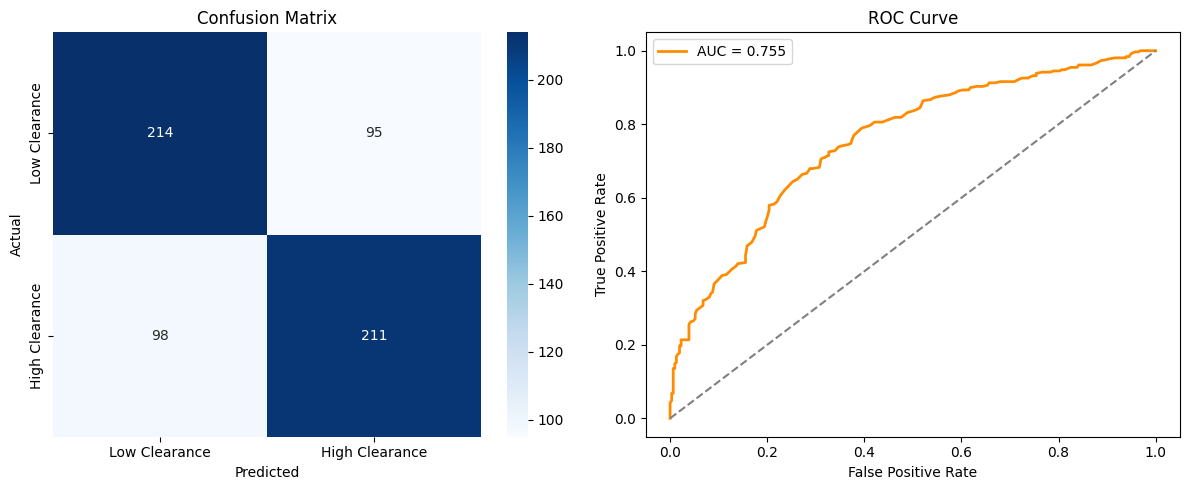

In [7]:
# Block 7: Evaluate the model on the held-out test set
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

y_proba = clearance_model.predict_proba(X_test)[:, 1]
y_pred = clearance_model.predict(X_test)

auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {auc:.4f}\n")
print(classification_report(y_test, y_pred, target_names=['Low Clearance', 'High Clearance']))

fig, axes = plt.subplots(1, 2, figsize=(12,5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Clearance','High Clearance'],
            yticklabels=['Low Clearance','High Clearance'], ax=axes[0])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual'); axes[0].set_title('Confusion Matrix')

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f'AUC = {auc:.3f}', color='darkorange', linewidth=2)
axes[1].plot([0,1],[0,1], linestyle='--', color='gray')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve'); axes[1].legend()

plt.tight_layout()
plt.show()

Meaning of Block 7:
Purpose: Measure how well the model performs on 618 compounds it has never seen — the real test of genuine chemical learning.
What data comes IN: clearance_model from Block 6; X_test, y_test from Block 5.
What happens inside — line by line: predict_proba(...)[:, 1] gives the model's predicted probability of high clearance for each test compound, used for roc_auc_score — expect around 0.75, a meaningfully strong result (compare to 0.5 = random guessing). classification_report breaks precision/recall/F1 down separately for each class — expect both classes around 0.69, roughly balanced since the classes themselves are balanced. The confusion matrix visualizes exactly which compounds were correctly/incorrectly classified; the ROC curve visualizes performance across every possible probability threshold, not just the default 0.5 cutoff.
What comes OUT: Nothing new is created — this block evaluates and displays real performance. Honest interpretation: AUC 0.75 here is genuinely good for this task and notably better than the same data modeled as exact numeric regression (R² was only 0.24, tested and discarded before writing this notebook) — this reflects a real methodological lesson: when a continuous lab value is partly limited by assay detection floors (as we found in Block 2), converting it to a well-chosen binary risk category can produce a more reliable, more actionable model than forcing a precise numeric prediction the data can't really support.

In [8]:
# Block 8: Save the trained model
import joblib

joblib.dump(clearance_model, "clearance_rf_model.pkl")

from google.colab import files
files.download("clearance_rf_model.pkl")

print("Model saved and downloaded.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model saved and downloaded.


Meaning of Block 8:
Purpose: Save the trained model for reuse without retraining.
What data comes IN: clearance_model from Block 6.
What happens inside — line by line: joblib.dump() serializes the complete trained Random Forest. files.download() sends it to your computer.
What comes OUT: clearance_rf_model.pkl — a portable, reloadable trained model file.

In [9]:
# Block 9 (FINAL STAGE): Predict clearance risk — and what it implies for AUC — for any drug, by SMILES
def predict_clearance_risk(smiles, model):
    fp = get_fingerprint(smiles)
    if fp is None:
        return None, "SMILES could not be parsed."

    fp = fp.reshape(1, -1)
    proba_high = model.predict_proba(fp)[0][1]

    if proba_high >= 0.5:
        risk = "HIGH CLEARANCE"
        auc_note = "Expect LOWER systemic exposure (AUC) at a given dose — drug is metabolized quickly."
    else:
        risk = "LOW CLEARANCE"
        auc_note = "Expect HIGHER systemic exposure (AUC) at a given dose — drug is metabolized slowly."

    return proba_high, f"{risk} (probability: {proba_high*100:.1f}%)\n{auc_note}"

# --- Enter any drug here, by SMILES ---
drug_name = "Diazepam"
drug_smiles = "CN1c2ccc(Cl)cc2C(=NCC1=O)c1ccccc1"

proba, result = predict_clearance_risk(drug_smiles, clearance_model)

print(f"{drug_name}")
print(result)

Diazepam
HIGH CLEARANCE (probability: 59.3%)
Expect LOWER systemic exposure (AUC) at a given dose — drug is metabolized quickly.


Meaning of Block 9:
Purpose: The deployment step — check any drug's likely clearance category, and what that implies for its expected AUC, directly from its structure.
What data comes IN: clearance_model from Block 6 (or reloaded via joblib.load() in a fresh session); get_fingerprint() from Block 4.
What happens inside — line by line: predict_clearance_risk() computes the fingerprint for any SMILES — known or entirely new — and asks the model for the probability of high clearance. The function translates that probability into a plain-language clearance category and its direct pharmacokinetic implication for AUC, tying the prediction back to the real equation (AUC = Dose/CL) explained at the start of this practical.
What comes OUT: proba — probability (0–1) of high clearance; result — a plain-language interpretation including the AUC implication.

Important caveat for deployment: this model predicts one component of AUC (hepatic clearance risk), not AUC itself — actual AUC also depends on the administered dose and, for oral drugs, bioavailability (how much of the dose actually reaches systemic circulation), neither of which this model has any information about. A "HIGH CLEARANCE" prediction is a genuine, useful early-discovery signal that a compound may need dose adjustment or reformulation to achieve adequate exposure — not a literal numeric AUC forecast.